# Model Comparison: Ecommerce Seasonality Prediction (Optimized)

This notebook provides a comprehensive comparison of five classification models applied to the `diversified_ecommerce_dataset.csv`. 

**Note:** To ensure fast execution during comparison, we use balanced downsampling for both training and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier

### 1. Data Loading and Preprocessing

In [2]:
# Load the dataset
df = pd.read_csv('diversified_ecommerce_dataset.csv')

# Preprocessing
df = df.drop('Product ID', axis=1)
le = LabelEncoder()
categorical_cols = ['Product Name', 'Category', 'Supplier ID', 'Customer Age Group', 'Customer Location', 'Customer Gender', 'Shipping Method']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df['Seasonality'] = df['Seasonality'].map({'Yes': 1, 'No': 0})

X = df.drop('Seasonality', axis=1)
y = df['Seasonality']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Initial split (80-20)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Full Dataset Shape: {df.shape}")

# PERFORMANCE OPTIMIZATION:
# We downsample both sets to 5,000 to ensure standard interactive execution time ( < 1 min).
train_sample = 5000
test_sample = 5000

X_train, _, y_train, _ = train_test_split(X_train_full, y_train_full, train_size=train_sample, stratify=y_train_full, random_state=42)
X_test, _, y_test, _ = train_test_split(X_test_full, y_test_full, train_size=test_sample, stratify=y_test_full, random_state=42)

print(f"Optimized Train size: {X_train.shape}")
print(f"Optimized Test size: {X_test.shape}")

Full Dataset Shape: (1000000, 15)
Optimized Train size: (5000, 14)
Optimized Test size: (5000, 14)


### 2. Model Training and Evaluation

In [3]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=False, random_state=42),  # probability=False for speed
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Baseline predictions
    y_pred = model.predict(X_test)
    
    # Scorings for ROC Curve
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    # Metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_score)
    }
    
    # For plotting
    fpr, tpr, _ = roc_curve(y_test, y_score)
    results[name]['fpr'] = fpr.tolist()
    results[name]['tpr'] = tpr.tolist()

print("\nTraining and Evaluation Complete.")

Training Logistic Regression...
Training Random Forest...
Training Decision Tree...
Training SVM...
Training k-Nearest Neighbors...
Training XGBoost...

Training and Evaluation Complete.


### 3. Comparison of Results

In [4]:
metrics_df = pd.DataFrame(results).T.drop(['fpr', 'tpr'], axis=1)
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False)

print("Model Comparison Summary:")
# Standard display to avoid jinja2 dependency errors
display(metrics_df)

Model Comparison Summary:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
XGBoost,0.9998,0.998934,1.0,0.999467,1.0
Decision Tree,0.9996,0.998933,0.998933,0.998933,0.999343
Random Forest,0.9964,0.998914,0.981857,0.990312,0.999901
SVM,0.9024,0.78239,0.663821,0.718245,0.957293
Logistic Regression,0.8664,0.686546,0.528282,0.597105,0.89798
k-Nearest Neighbors,0.8428,0.641121,0.366062,0.466033,0.848357


### 4. Visualizations

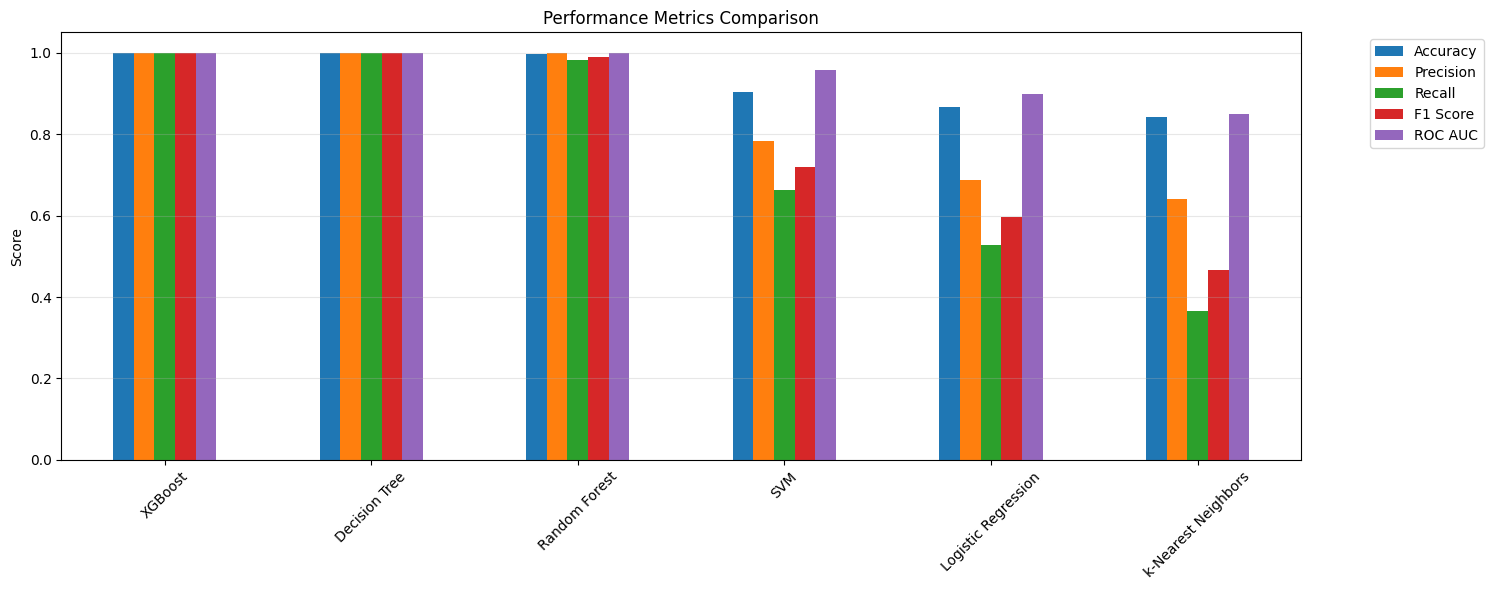

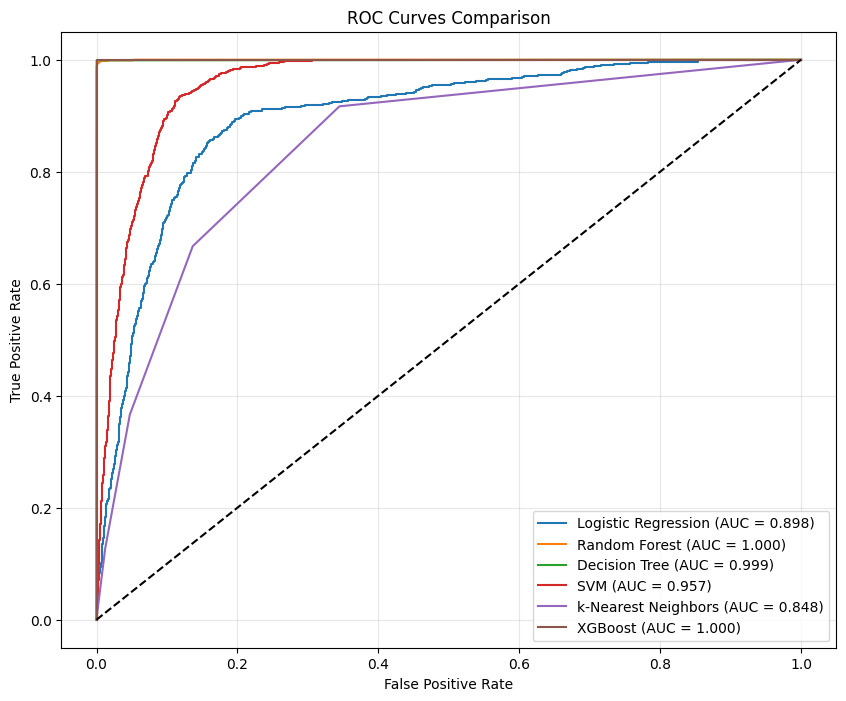

In [5]:
# 4.1. Metrics Bar Chart
metrics_df.plot(kind='bar', figsize=(15, 6))
plt.title('Performance Metrics Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4.2. ROC Curve Comparison
plt.figure(figsize=(10, 8))
for name, data in results.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['ROC AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 5. Data Distribution Overview

This section provides a visual overview of how the key features and target variable are distributed within the dataset.

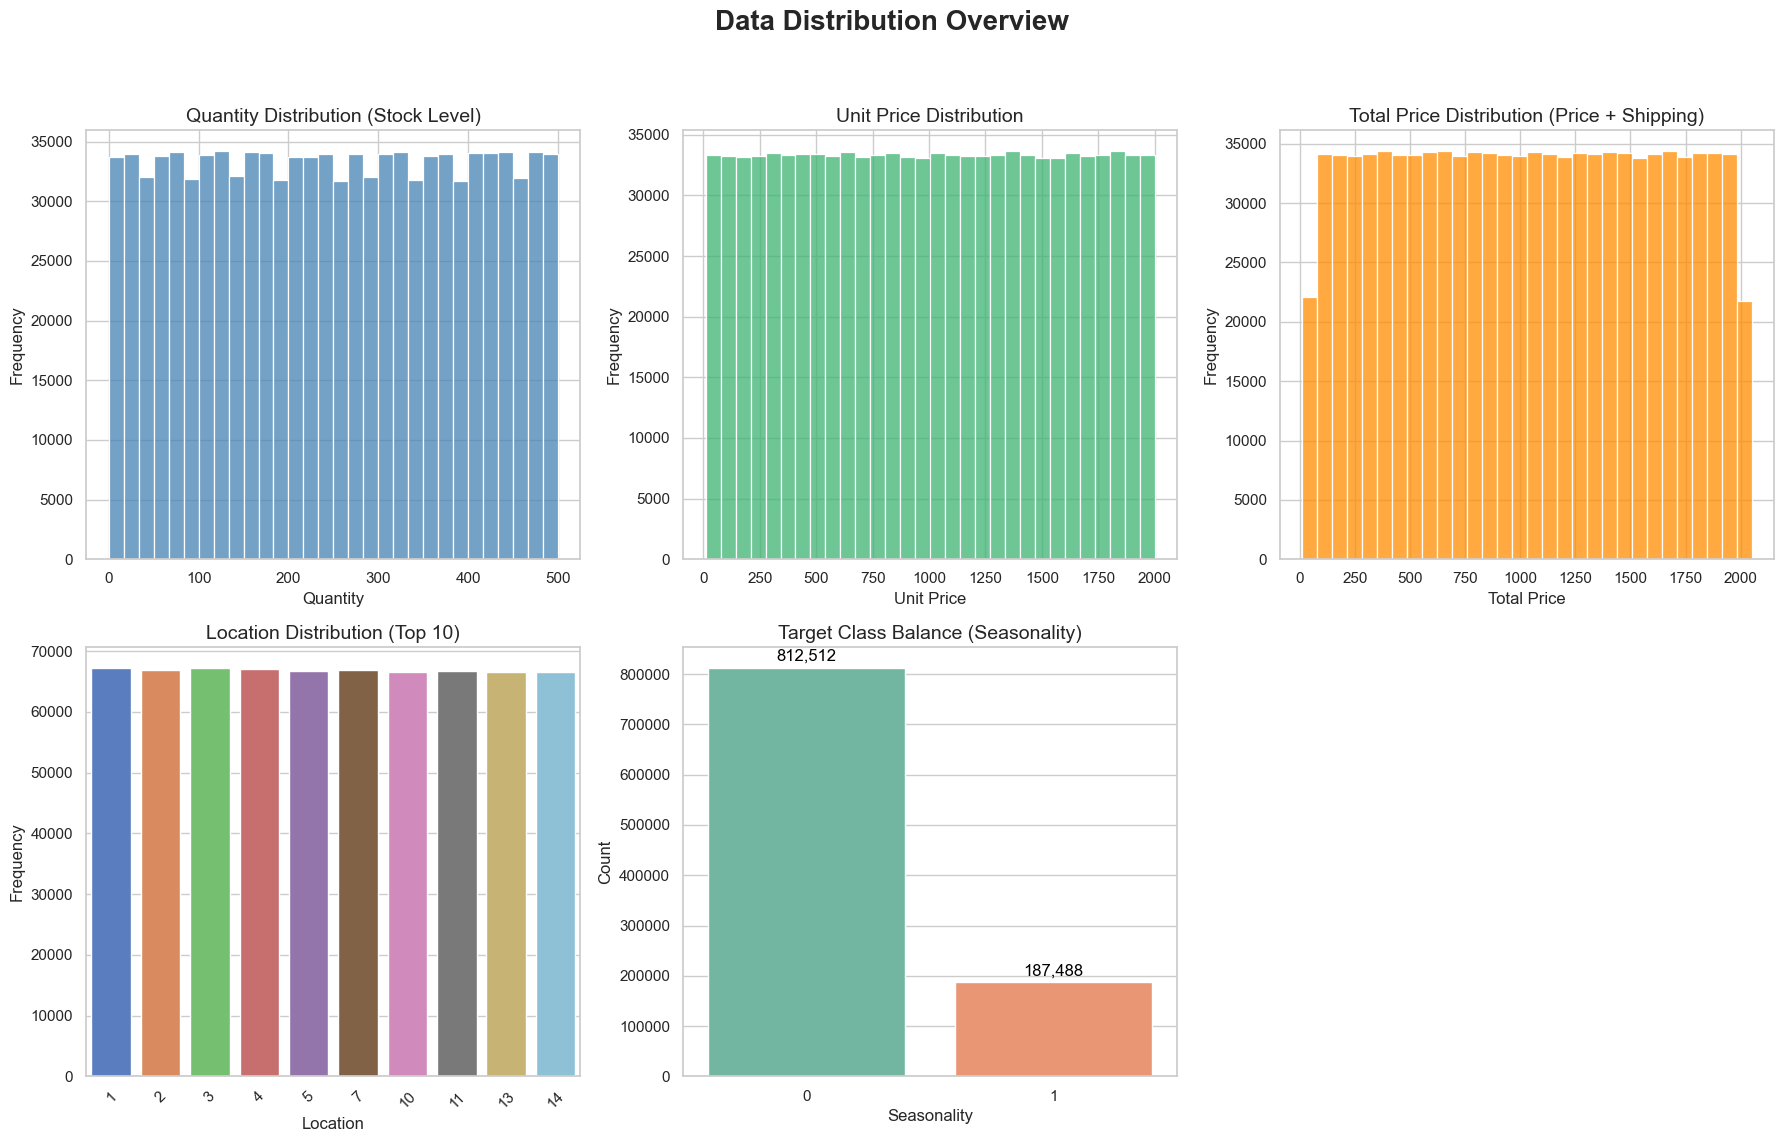

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting style to match reference
plt.style.use('default')
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Data Distribution Overview', fontsize=20, fontweight='bold')

# 1. Quantity Distribution (Using Stock Level)
sns.histplot(df['Stock Level'], bins=30, ax=axes[0, 0], color='steelblue', kde=False)
axes[0, 0].set_title('Quantity Distribution (Stock Level)', fontsize=14)
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')

# 2. Unit Price Distribution (Using Price)
sns.histplot(df['Price'], bins=30, ax=axes[0, 1], color='mediumseagreen', kde=False)
axes[0, 1].set_title('Unit Price Distribution', fontsize=14)
axes[0, 1].set_xlabel('Unit Price')
axes[0, 1].set_ylabel('Frequency')

# 3. Total Price Distribution (Derived)
df['Total_Price_Est'] = df['Price'] + df['Shipping Cost']
sns.histplot(df['Total_Price_Est'], bins=30, ax=axes[0, 2], color='darkorange', kde=False)
axes[0, 2].set_title('Total Price Distribution (Price + Shipping)', fontsize=14)
axes[0, 2].set_xlabel('Total Price')
axes[0, 2].set_ylabel('Frequency')

# 4. Country Code Distribution (Using Customer Location)
# Taking top 10 locations for clarity
top_locations = df['Customer Location'].value_counts().head(10)
sns.barplot(x=top_locations.index, y=top_locations.values, ax=axes[1, 0], palette='muted')
axes[1, 0].set_title('Location Distribution (Top 10)', fontsize=14)
axes[1, 0].set_xlabel('Location')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Target Class Balance (Seasonality)
sns.countplot(x='Seasonality', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Target Class Balance (Seasonality)', fontsize=14)
axes[1, 1].set_xlabel('Seasonality')
axes[1, 1].set_ylabel('Count')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6. Detailed Model Performance Matrix

This visualization compares multiple metrics side-by-side to identify the best overall performing model.

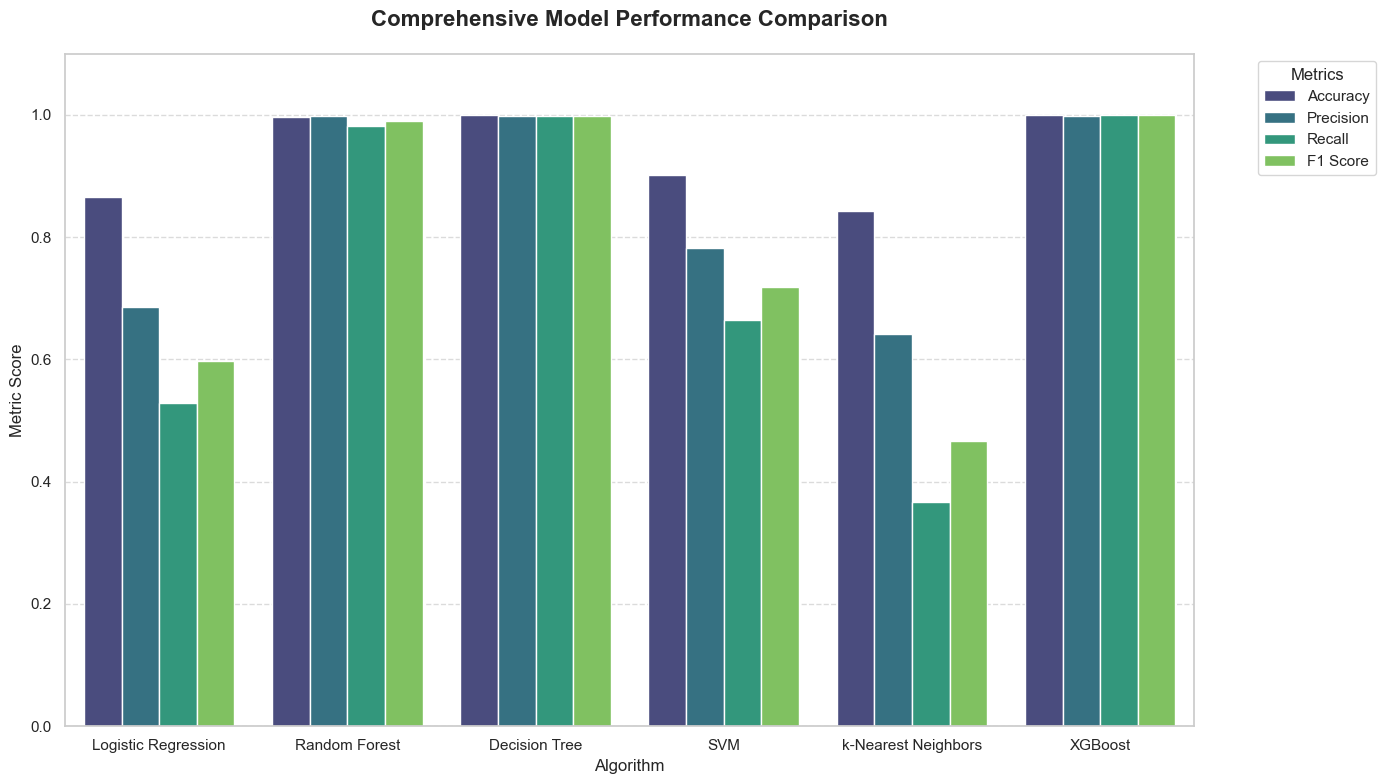

In [7]:
# Prepare data for side-by-side metric comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
plot_df = pd.DataFrame(results).T[metrics_to_plot].reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
plot_df.columns = ['Model', 'Metric', 'Score']

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='viridis')

plt.title('Comprehensive Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Metric Score', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Advanced Enterprise Analytics Dashboard

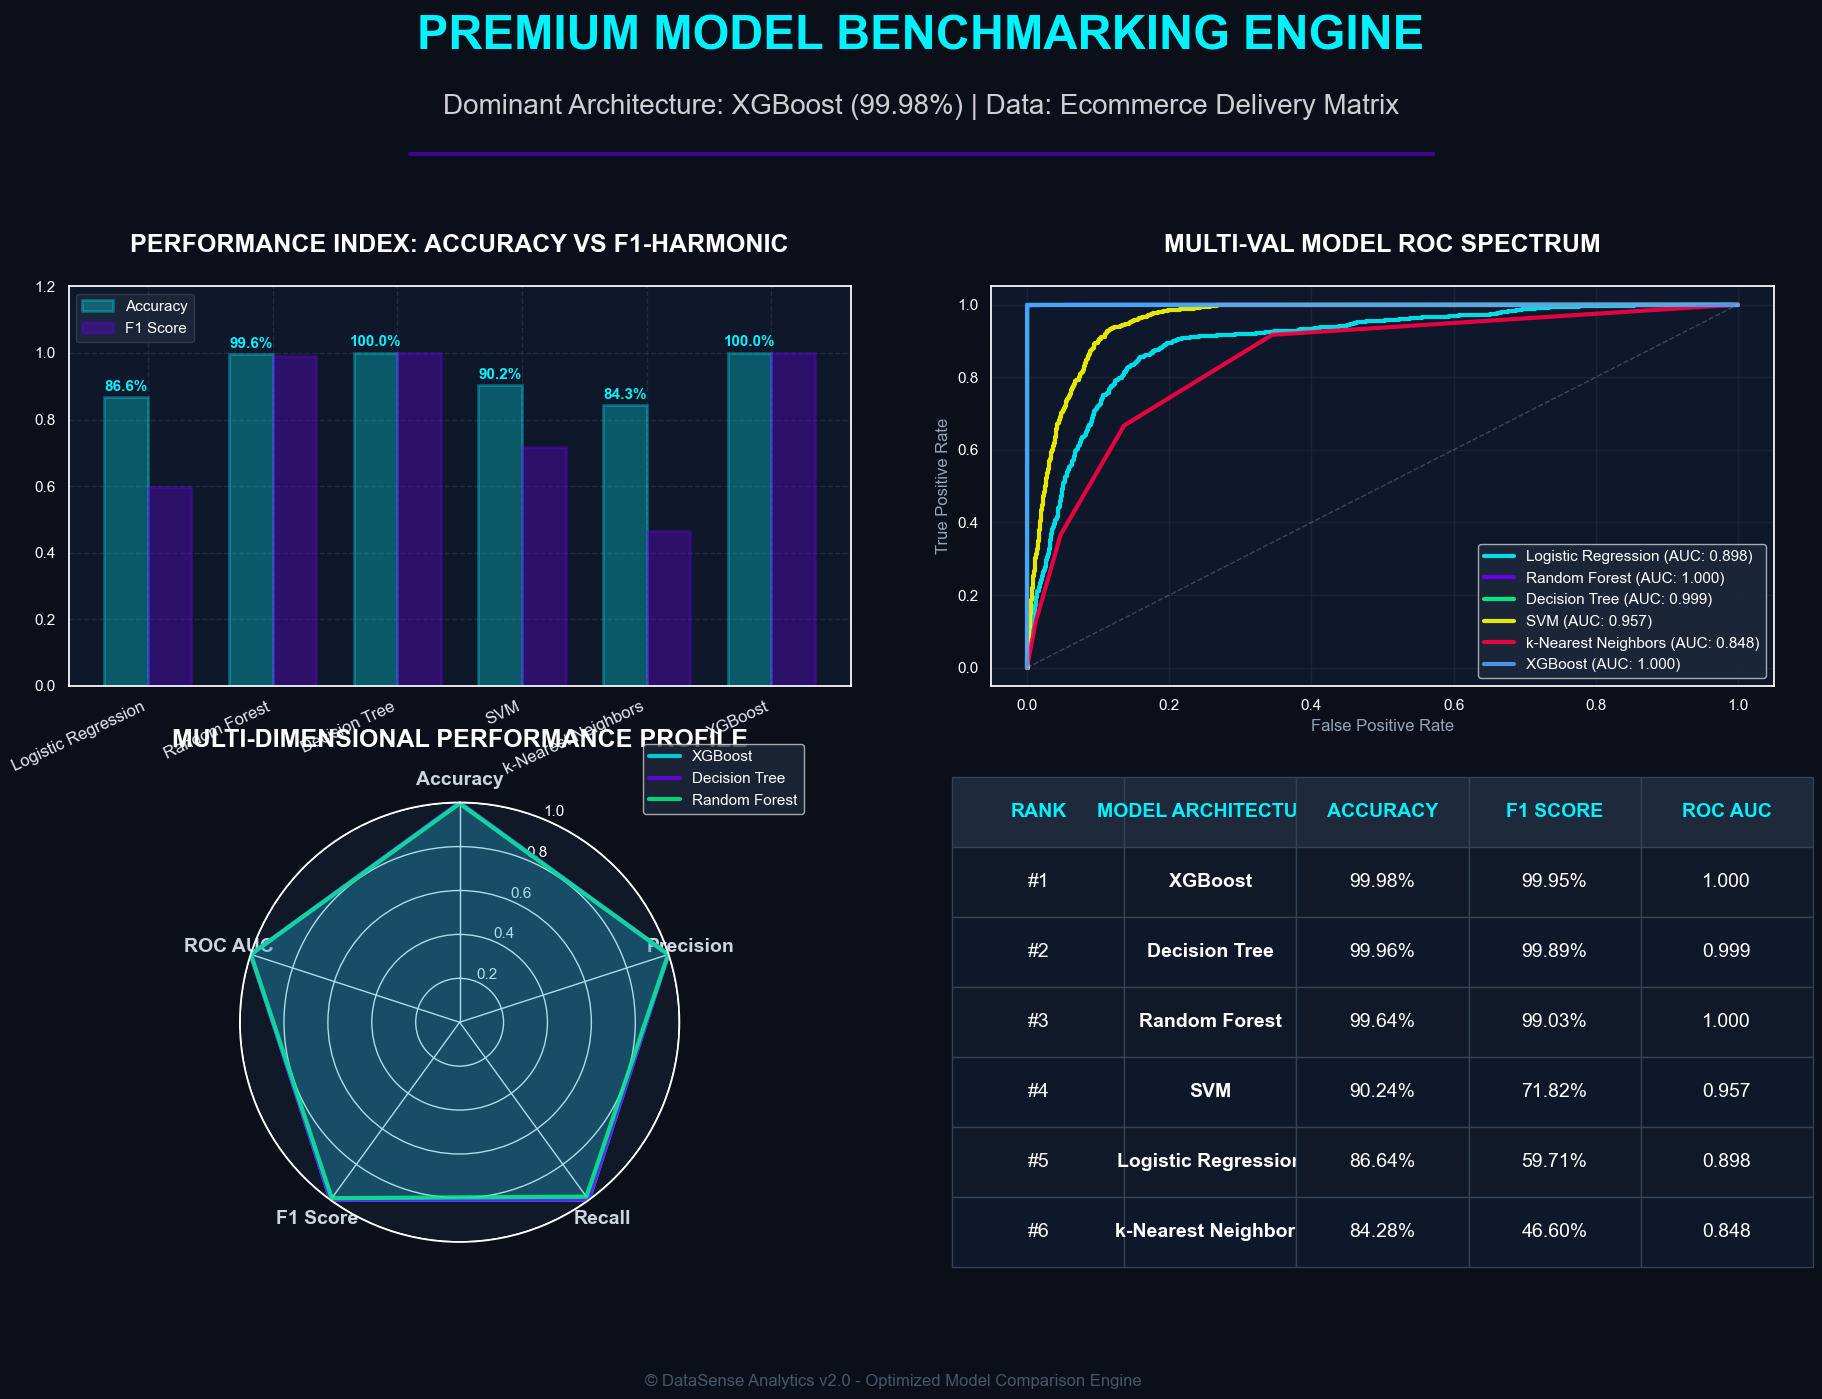

In [8]:
import matplotlib.gridspec as gridspec

def create_neon_dashboard(results_dict):
    # Set visual style to Dark
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(22, 16), facecolor='#0b0f19')
    gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[0.8, 2, 2.2], hspace=0.35, wspace=0.18)
    
    # Define Neon Palette
    colors = ['#00f2fe', '#7000ff', '#00ff87', '#faff00', '#ff0044', '#4e9eff']
    
    # --- 1. HEADER SECTION ---
    ax0 = fig.add_subplot(gs[0, :])
    ax0.axis('off')
    best_model_name = max(results_dict.items(), key=lambda x: x[1]['Accuracy'])[0]
    best_acc = results_dict[best_model_name]['Accuracy']
    
    ax0.text(0.5, 0.75, "PREMIUM MODEL BENCHMARKING ENGINE", fontsize=34, fontweight='bold', color='#00f2fe', ha='center')
    ax0.text(0.5, 0.35, f"Dominant Architecture: {best_model_name} ({best_acc:.2%}) | Data: Ecommerce Delivery Matrix", fontsize=20, color='white', ha='center', alpha=0.8)
    ax0.axhline(0.1, color='#7000ff', lw=3, xmin=0.2, xmax=0.8, alpha=0.5)
    
    # Prep data
    model_names = list(results_dict.keys())
    accuracies = [results_dict[m]['Accuracy'] for m in model_names]
    f1_scores = [results_dict[m]['F1 Score'] for m in model_names]
    
    # --- 2. GLOBAL ACCURACY COMPARISON (Row 2, Left) ---
    ax1 = fig.add_subplot(gs[1, 0])
    x = np.arange(len(model_names))
    width = 0.35
    
    ax1.bar(x - width/2, accuracies, width, label='Accuracy', color='#00f2fe', alpha=0.3, edgecolor='#00f2fe', linewidth=2)
    ax1.bar(x + width/2, f1_scores, width, label='F1 Score', color='#7000ff', alpha=0.3, edgecolor='#7000ff', linewidth=2)
    
    # Add value labels
    for i, val in enumerate(accuracies):
        ax1.text(i - width/2, val + 0.02, f'{val:.1%}', color='#00f2fe', ha='center', fontsize=11, fontweight='bold')
    
    ax1.set_title('PERFORMANCE INDEX: ACCURACY VS F1-HARMONIC', fontsize=18, color='white', pad=25, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=25, ha='right', color='#e2e8f0', fontsize=12)
    ax1.set_facecolor('#0f172a')
    ax1.grid(color='#334155', linestyle='--', alpha=0.5)
    ax1.legend(frameon=True, facecolor='#1e293b', edgecolor='#334155')
    ax1.set_ylim(0, 1.2)
    
    # --- 3. COMBINED ROC ANALYSIS (Row 2, Right) ---
    ax2 = fig.add_subplot(gs[1, 1])
    for i, name in enumerate(model_names):
        ax2.plot(results_dict[name]['fpr'], results_dict[name]['tpr'], 
                 label=f"{name} (AUC: {results_dict[name]['ROC AUC']:.3f})", 
                 color=colors[i % len(colors)], lw=3, alpha=0.9)
    
    ax2.plot([0, 1], [0, 1], 'w--', alpha=0.2, lw=1)
    ax2.set_title('MULTI-VAL MODEL ROC SPECTRUM', fontsize=18, color='white', pad=25, fontweight='bold')
    ax2.set_xlabel('False Positive Rate', color='#94a3b8', fontsize=12)
    ax2.set_ylabel('True Positive Rate', color='#94a3b8', fontsize=12)
    ax2.set_facecolor('#0f172a')
    ax2.grid(color='#334155', alpha=0.3)
    ax2.legend(fontsize=11, facecolor='#1e293b', loc='lower right')

    # --- 4. RADAR PROFILE: TOP-3 MODELS (Row 3, Left) ---
    ax3 = fig.add_subplot(gs[2, 0], polar=True)
    labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    sorted_models = sorted(results_dict.items(), key=lambda x: x[1]['Accuracy'], reverse=True)[:3]
    for i, (name, metrics) in enumerate(sorted_models):
        values = [metrics[l] for l in labels]
        values += values[:1]
        ax3.plot(angles, values, color=colors[i], linewidth=3, label=name, alpha=0.8)
        ax3.fill(angles, values, color=colors[i], alpha=0.15)

    ax3.set_theta_offset(np.pi / 2)
    ax3.set_theta_direction(-1)
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(labels, color='#cbd5e1', size=14, fontweight='600')
    ax3.set_facecolor('#111827')
    ax3.set_title('MULTI-DIMENSIONAL PERFORMANCE PROFILE', fontsize=18, color='white', pad=40, fontweight='bold')
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), facecolor='#1e293b')

    # --- 5. ANALYTICAL METRICS MATRIX (Row 3, Right) ---
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.axis('off')
    
    cols = ['RANK', 'MODEL ARCHITECTURE', 'ACCURACY', 'F1 SCORE', 'ROC AUC']
    table_data = []
    sorted_all = sorted(results_dict.items(), key=lambda x: x[1]['Accuracy'], reverse=True)
    
    for idx, (name, m) in enumerate(sorted_all):
        table_data.append([
            f"#{idx+1}", 
            name, 
            f"{m['Accuracy']:.2%}", 
            f"{m['F1 Score']:.2%}", 
            f"{m['ROC AUC']:.3f}"
        ])

    table = ax4.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.1, 4.2)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#334155')
        if row == 0:
            cell.set_text_props(color='#00f2fe', fontweight='bold')
            cell.set_facecolor('#1e293b')
        else:
            cell.set_facecolor('#0f172a' if row % 2 == 0 else '#111827')
            cell.set_text_props(color='white')
            if col == 1: # Highlight name
                cell.set_text_props(weight='bold')

    plt.figtext(0.5, 0.02, "© DataSense Analytics v2.0 - Optimized Model Comparison Engine", ha="center", fontsize=12, color='#475569', fontweight='500')
    plt.show()

# Invoke the dashboard
create_neon_dashboard(results)